In [0]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from mlflow import MlflowClient

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [0]:
EXPERIMENT_NAME = "/Shared/Football_MLflow_Experiment"

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks-uc")
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Registry URI:", mlflow.get_registry_uri())
print("Experiment:", EXPERIMENT_NAME)

Tracking URI: databricks
Registry URI: databricks-uc
Experiment: /Shared/Football_MLflow_Experiment


In [0]:
DATA_DIRECTORY = "/Volumes/workspace/default/football_data"

TEST_PATH = (
    f"{DATA_DIRECTORY}/football_test.csv"
)

CHAMPION_INFO_PATH = (
    f"{DATA_DIRECTORY}/champion_run_info.csv"
)

CHAMPION_REGISTRATION_PATH = (
    f"{DATA_DIRECTORY}/champion_registration_info.csv"
)

PROMOTION_RECORD_PATH = (
    f"{DATA_DIRECTORY}/promotion_record.csv"
)

INFERENCE_RESULTS_PATH = (
    f"{DATA_DIRECTORY}/promoted_champion_predictions.csv"
)

INFERENCE_SUMMARY_PATH = (
    f"{DATA_DIRECTORY}/promoted_champion_inference_summary.csv"
)

SAMPLE_PREDICTIONS_PATH = (
    f"{DATA_DIRECTORY}/promoted_champion_prediction_sample.csv"
)

REGISTERED_MODEL_NAME = (
    "workspace.default.football_match_result_model"
)

CHAMPION_ALIAS = "champion"

CHAMPION_MODEL_URI = (
    f"models:/{REGISTERED_MODEL_NAME}"
    f"@{CHAMPION_ALIAS}"
)

TARGET_COLUMN = "match_result"

LEAKAGE_COLUMNS = [
    "home_score",
    "away_score"
]

METRIC_TOLERANCE = 1e-8

print("Champion model URI:", CHAMPION_MODEL_URI)

Champion model URI: models:/workspace.default.football_match_result_model@champion


In [0]:
required_files = [
    TEST_PATH,
    CHAMPION_INFO_PATH,
    CHAMPION_REGISTRATION_PATH,
    PROMOTION_RECORD_PATH
]

missing_files = [
    path
    for path in required_files
    if not os.path.exists(path)
]

assert not missing_files, (
    "Required files are missing: "
    f"{missing_files}"
)

print("All required files are available.")

All required files are available.


In [0]:
champion_info_df = pd.read_csv(
    CHAMPION_INFO_PATH
)

champion_registration_df = pd.read_csv(
    CHAMPION_REGISTRATION_PATH
)

promotion_record_df = pd.read_csv(
    PROMOTION_RECORD_PATH
)

print("Current Champion metadata:")
display(champion_info_df)

print("Champion registration metadata:")
display(champion_registration_df)

print("Promotion record:")
display(promotion_record_df)

Current Champion metadata:


model_role,algorithm,run_id,model_uri,primary_metric,primary_metric_value,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,training_rows,testing_rows,training_time_seconds,prediction_time_seconds,champion_algorithm,champion_run_id,champion_model_version,champion_macro_f1,macro_f1_improvement,relative_improvement_percentage,promotion_eligible,promotion_recommendation,registration_status,registered_model_version,alias_status,registered_model_name,registered_model_alias,alias_model_uri,promotion_status,promotion_timestamp_utc,previous_champion_algorithm,previous_champion_run_id,previous_champion_version,previous_champion_macro_f1
champion,LogisticRegression,80ac2ed817e940c9a66f4e99f15b08f4,models:/m-d7e371663ec74ae8930885ebaa2a6cc2,test_f1_macro,0.6222097633743984,0.6515,0.6446662708271728,0.6136885178601231,0.6222097633743984,0.6434775072688667,15999,4000,25.322230577468872,0.0281131267547607,DecisionTreeClassifier,3fa9c04ecf3d4f1597aa3bd68f650d2f,4,0.3407115240453506,0.2814982393290478,82.62069799892615,true,PROMOTED,READY,5,assigned,workspace.default.football_match_result_model,champion,models:/workspace.default.football_match_result_model@champion,promoted,2026-07-27T15:13:08.147727+00:00,DecisionTreeClassifier,3fa9c04ecf3d4f1597aa3bd68f650d2f,4,0.3407115240453506


Champion registration metadata:


registered_model_name,registered_model_version,alias,alias_model_uri,algorithm,run_id,source_model_uri,primary_metric,primary_metric_value,registration_status,alias_status,model_role,previous_champion_version,previous_champion_run_id,promotion_timestamp_utc
workspace.default.football_match_result_model,5,champion,models:/workspace.default.football_match_result_model@champion,LogisticRegression,80ac2ed817e940c9a66f4e99f15b08f4,models:/m-d7e371663ec74ae8930885ebaa2a6cc2,test_f1_macro,0.6222097633743984,READY,assigned,champion,4,3fa9c04ecf3d4f1597aa3bd68f650d2f,2026-07-27T15:13:08.147727+00:00


Promotion record:


promotion_timestamp_utc,registered_model_name,promotion_metric,minimum_required_improvement,old_champion_algorithm,old_champion_version,old_champion_run_id,old_champion_macro_f1,challenger_algorithm,challenger_run_id,challenger_source_model_uri,challenger_macro_f1,absolute_improvement,relative_improvement_percentage,promotion_eligible,promotion_decision,new_champion_version,new_champion_alias,new_champion_alias_uri,alias_verification,prediction_verification,old_version_preserved
2026-07-27T15:13:08.147727+00:00,workspace.default.football_match_result_model,test_f1_macro,0.0,DecisionTreeClassifier,4,3fa9c04ecf3d4f1597aa3bd68f650d2f,0.3407115240453506,LogisticRegression,80ac2ed817e940c9a66f4e99f15b08f4,models:/m-d7e371663ec74ae8930885ebaa2a6cc2,0.6222097633743984,0.2814982393290478,82.62069799892615,true,PROMOTED,5,champion,models:/workspace.default.football_match_result_model@champion,PASSED,PASSED,true


In [0]:
import pandas as pd


# ---------------------------------------------------------
# Helper function to normalize MLflow model version values
# ---------------------------------------------------------
def normalize_model_version(value):
    """
    Convert model-version values such as:
    5, 5.0, "5", or "5.0"
    into the consistent string format "5".
    """

    if pd.isna(value):
        raise ValueError(
            "The registered model version is missing."
        )

    return str(int(float(value)))


# ---------------------------------------------------------
# Validate that each metadata file contains one final record
# ---------------------------------------------------------
assert len(champion_info_df) == 1, (
    "champion_info_df should contain exactly one row, "
    f"but found {len(champion_info_df)} rows."
)

assert len(champion_registration_df) == 1, (
    "champion_registration_df should contain exactly one row, "
    f"but found {len(champion_registration_df)} rows."
)

assert len(promotion_record_df) == 1, (
    "promotion_record_df should contain exactly one row, "
    f"but found {len(promotion_record_df)} rows."
)


# ---------------------------------------------------------
# Extract the first and only record from each DataFrame
# ---------------------------------------------------------
champion_record = champion_info_df.iloc[0]

registration_record = (
    champion_registration_df.iloc[0]
)

promotion_record = promotion_record_df.iloc[0]


# ---------------------------------------------------------
# Read expected Champion information
# ---------------------------------------------------------
expected_algorithm = str(
    champion_record["algorithm"]
).strip()

expected_run_id = str(
    champion_record["run_id"]
).strip()

expected_version = normalize_model_version(
    champion_record[
        "registered_model_version"
    ]
)

expected_macro_f1 = float(
    champion_record[
        "primary_metric_value"
    ]
)

expected_accuracy = float(
    champion_record[
        "test_accuracy"
    ]
)


# ---------------------------------------------------------
# Read registration information
# ---------------------------------------------------------
registered_algorithm = str(
    registration_record["algorithm"]
).strip()

registered_run_id = str(
    registration_record["run_id"]
).strip()

registered_version = normalize_model_version(
    registration_record[
        "registered_model_version"
    ]
)


# ---------------------------------------------------------
# Read promotion information
# ---------------------------------------------------------
promotion_decision = str(
    promotion_record[
        "promotion_decision"
    ]
).strip().upper()

promoted_version = normalize_model_version(
    promotion_record[
        "new_champion_version"
    ]
)


# Some promotion files may contain the new Champion run ID.
# Validate it only when that column exists.
if (
    "new_champion_run_id"
    in promotion_record_df.columns
):

    promoted_run_id = str(
        promotion_record[
            "new_champion_run_id"
        ]
    ).strip()

else:
    promoted_run_id = expected_run_id


# ---------------------------------------------------------
# Print expected metadata
# ---------------------------------------------------------
print("=" * 70)
print("PROMOTED CHAMPION METADATA")
print("=" * 70)

print(
    "Expected algorithm:",
    expected_algorithm
)

print(
    "Expected version:",
    expected_version
)

print(
    "Expected run ID:",
    expected_run_id
)

print(
    "Expected accuracy:",
    round(expected_accuracy, 4)
)

print(
    "Expected Macro F1:",
    round(expected_macro_f1, 4)
)


# ---------------------------------------------------------
# Validate the promoted algorithm
# ---------------------------------------------------------
assert expected_algorithm == "LogisticRegression", (
    "Expected the promoted Champion to be "
    f"LogisticRegression, but found "
    f"{expected_algorithm}."
)


# ---------------------------------------------------------
# Validate the promotion decision
# ---------------------------------------------------------
assert promotion_decision == "PROMOTED", (
    "Expected promotion decision PROMOTED, "
    f"but found {promotion_decision}."
)


# ---------------------------------------------------------
# Validate version consistency
# ---------------------------------------------------------
assert promoted_version == expected_version, (
    "Promotion record and Champion metadata contain "
    "different model versions. "
    f"Promotion record: {promoted_version}; "
    f"Champion metadata: {expected_version}."
)

assert registered_version == expected_version, (
    "Registration record and Champion metadata contain "
    "different model versions. "
    f"Registration record: {registered_version}; "
    f"Champion metadata: {expected_version}."
)


# ---------------------------------------------------------
# Validate algorithm consistency
# ---------------------------------------------------------
assert registered_algorithm == expected_algorithm, (
    "Registration record and Champion metadata contain "
    "different algorithms. "
    f"Registration record: {registered_algorithm}; "
    f"Champion metadata: {expected_algorithm}."
)


# ---------------------------------------------------------
# Validate run-ID consistency
# ---------------------------------------------------------
assert registered_run_id == expected_run_id, (
    "Registration record and Champion metadata contain "
    "different run IDs. "
    f"Registration record: {registered_run_id}; "
    f"Champion metadata: {expected_run_id}."
)

assert promoted_run_id == expected_run_id, (
    "Promotion record and Champion metadata contain "
    "different run IDs. "
    f"Promotion record: {promoted_run_id}; "
    f"Champion metadata: {expected_run_id}."
)


# ---------------------------------------------------------
# Validate metric ranges
# ---------------------------------------------------------
assert 0.0 <= expected_accuracy <= 1.0, (
    "Accuracy must be between 0 and 1, "
    f"but found {expected_accuracy}."
)

assert 0.0 <= expected_macro_f1 <= 1.0, (
    "Macro F1 must be between 0 and 1, "
    f"but found {expected_macro_f1}."
)


# ---------------------------------------------------------
# Final successful validation message
# ---------------------------------------------------------
print("-" * 70)

print(
    "Promotion decision:",
    promotion_decision
)

print(
    "Registered version:",
    registered_version
)

print(
    "Promoted Champion version:",
    promoted_version
)

print(
    "Promoted Champion algorithm:",
    expected_algorithm
)

print("-" * 70)
print("PROMOTED CHAMPION METADATA VALIDATED SUCCESSFULLY")
print("=" * 70)

PROMOTED CHAMPION METADATA
Expected algorithm: LogisticRegression
Expected version: 5
Expected run ID: 80ac2ed817e940c9a66f4e99f15b08f4
Expected accuracy: 0.6515
Expected Macro F1: 0.6222
----------------------------------------------------------------------
Promotion decision: PROMOTED
Registered version: 5
Promoted Champion version: 5
Promoted Champion algorithm: LogisticRegression
----------------------------------------------------------------------
PROMOTED CHAMPION METADATA VALIDATED SUCCESSFULLY


In [0]:
client = MlflowClient()

alias_model_version = (
    client.get_model_version_by_alias(
        name=REGISTERED_MODEL_NAME,
        alias=CHAMPION_ALIAS
    )
)

resolved_version = str(
    alias_model_version.version
)

resolved_run_id = str(
    alias_model_version.run_id
)

resolved_aliases = list(
    alias_model_version.aliases
)

print("Resolved model version:", resolved_version)
print("Resolved run ID:", resolved_run_id)
print("Aliases:", resolved_aliases)

Resolved model version: 5
Resolved run ID: 80ac2ed817e940c9a66f4e99f15b08f4
Aliases: ['champion']


In [0]:
assert resolved_version == expected_version, (
    "The champion alias does not point to the "
    "promoted model version."
)

assert resolved_run_id == expected_run_id, (
    "The alias-resolved run ID does not match "
    "the promoted Champion run ID."
)

assert CHAMPION_ALIAS in resolved_aliases

print("=" * 65)
print("CHAMPION ALIAS VERIFICATION PASSED")
print("=" * 65)

print(
    f"The '{CHAMPION_ALIAS}' alias points to "
    f"version {resolved_version}."
)

CHAMPION ALIAS VERIFICATION PASSED
The 'champion' alias points to version 5.


In [0]:
test_df = pd.read_csv(
    TEST_PATH
)

print("Test dataset shape:", test_df.shape)

assert TARGET_COLUMN in test_df.columns
assert len(test_df) == 4000

display(test_df.head())

Test dataset shape: (4000, 58)


Country,League,home_team,away_team,season_year,expected_goals_xg_home,expected_goals_xg_host,Ball_Possession_Home,Ball_Possession_Host,Goal_Attempts_Home,Goal_Attempts_Host,Shots_on_Goal_Home,Shots_on_Goal_Host,Shots_off_Goal_Home,Shots_off_Goal_Host,Blocked_Shots_Home,Blocked_Shots_Host,Free_Kicks_Home,Free_Kicks_Host,Corner_Kicks_Home,Corner_Kicks_Host,Offsides_Home,Offsides_Host,Throw_ins_Home,Throw_ins_Host,Goalkeeper_Saves_Home,Goalkeeper_Saves_Host,Fouls_Home,Fouls_Host,Red_Cards_Home,Red_Cards_Host,Yellow_Cards_Home,Yellow_Cards_Host,Tackles_Home,Tackles_Host,Interceptions_Home,Interceptions_Host,Clearances_Completed_Home,Clearances_Completed_Host,Total_Passes_Home,Total_Passes_Host,Completed_Passes_Home,Completed_Passes_Host,Pass_Success_per_Home,Pass_Success_per_Host,Crosses_Completed_Home,Crosses_Completed_Host,Attacks_Home,Attacks_Host,Dangerous_Attacks_Home,Dangerous_Attacks_Host,Distance_Covered_(km)_Home,Distance_Covered_(km)_Host,referee,venue,capacity,attendance,match_result
Germany,2-bundesliga,Saarbrucken,B. Monchengladbach,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Away Win
France,Ligue-2,Laval,Red Star,null,null,null,56.0,44.0,16.0,7.0,5.0,3.0,11.0,4.0,null,null,22.0,9.0,9.0,1.0,null,null,25.0,22.0,2.0,4.0,null,null,null,null,0.0,2.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Delpech R. (Fra),Stade Francis Le Basser (Laval),null,null,Draw
Italy,Serie-a,Reggina,Juventus,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Stadio Oreste Granillo (Reggio Calabria),null,null,Away Win
England,Championship,Burnley,Coventry,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Turf Moor (Burnley),null,null,Away Win
Turkey,Super-lig,Gaziantepspor,Ankaragucu,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Home Win


In [0]:
available_leakage_columns = [
    column
    for column in LEAKAGE_COLUMNS
    if column in test_df.columns
]

inference_df = test_df.drop(
    columns=available_leakage_columns,
    errors="ignore"
).copy()

print(
    "Leakage columns removed:",
    available_leakage_columns
)

Leakage columns removed: []


In [0]:
X_test = inference_df.drop(
    columns=[TARGET_COLUMN]
).copy()

y_test = inference_df[
    TARGET_COLUMN
].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (4000, 57)
y_test shape: (4000,)


In [0]:
model_info = mlflow.models.get_model_info(
    CHAMPION_MODEL_URI
)

model_signature = model_info.signature

print("Model signature:")
print(model_signature)

Model signature:
inputs: 
  ['Country': string (required), 'League': string (required), 'home_team': string (required), 'away_team': string (required), 'expected_goals_xg_home': double (optional), 'expected_goals_xg_host': double (optional), 'Ball_Possession_Home': double (optional), 'Ball_Possession_Host': double (optional), 'Goal_Attempts_Home': double (optional), 'Goal_Attempts_Host': double (optional), 'Shots_on_Goal_Home': double (optional), 'Shots_on_Goal_Host': double (optional), 'Shots_off_Goal_Home': double (optional), 'Shots_off_Goal_Host': double (optional), 'Blocked_Shots_Home': double (optional), 'Blocked_Shots_Host': double (optional), 'Free_Kicks_Home': double (optional), 'Free_Kicks_Host': double (optional), 'Corner_Kicks_Home': double (optional), 'Corner_Kicks_Host': double (optional), 'Offsides_Home': double (optional), 'Offsides_Host': double (optional), 'Throw_ins_Home': double (optional), 'Throw_ins_Host': double (optional), 'Goalkeeper_Saves_Home': double (optiona

In [0]:
if (
    model_signature is not None
    and model_signature.inputs is not None
):

    expected_input_columns = [
        input_spec.name
        for input_spec
        in model_signature.inputs.inputs
        if input_spec.name is not None
    ]

    missing_input_columns = [
        column
        for column in expected_input_columns
        if column not in X_test.columns
    ]

    assert not missing_input_columns, (
        "Test dataset is missing required model inputs: "
        f"{missing_input_columns}"
    )

    X_test_aligned = X_test[
        expected_input_columns
    ].copy()

else:
    expected_input_columns = list(
        X_test.columns
    )

    X_test_aligned = X_test.copy()

print(
    "Aligned feature shape:",
    X_test_aligned.shape
)

Aligned feature shape: (4000, 44)


In [0]:
load_start_time = time.time()

champion_model = mlflow.sklearn.load_model(
    CHAMPION_MODEL_URI
)

model_load_time = (
    time.time() - load_start_time
)

print("Champion loaded through alias.")
print("Model type:", type(champion_model))

print(
    "Model load time:",
    round(model_load_time, 4),
    "seconds"
)

Champion loaded through alias.
Model type: <class 'sklearn.pipeline.Pipeline'>
Model load time: 4.8985 seconds


In [0]:
assert hasattr(
    champion_model,
    "named_steps"
), (
    "Expected an sklearn Pipeline."
)

pipeline_steps = list(
    champion_model.named_steps.keys()
)

print("Pipeline steps:", pipeline_steps)

assert "preprocessor" in pipeline_steps
assert "classifier" in pipeline_steps

loaded_classifier = (
    champion_model.named_steps[
        "classifier"
    ]
)

loaded_classifier_name = type(
    loaded_classifier
).__name__

print(
    "Loaded classifier:",
    loaded_classifier_name
)

assert (
    loaded_classifier_name
    == "LogisticRegression"
)

print(
    "The alias-loaded Champion is "
    "Logistic Regression."
)

Pipeline steps: ['preprocessor', 'classifier']
Loaded classifier: LogisticRegression
The alias-loaded Champion is Logistic Regression.


In [0]:
sample_features = (
    X_test_aligned.head(10).copy()
)

sample_actual_values = (
    y_test.head(10)
    .reset_index(drop=True)
)

sample_predictions = (
    champion_model.predict(
        sample_features
    )
)

sample_probabilities = (
    champion_model.predict_proba(
        sample_features
    )
)

sample_results_df = pd.DataFrame(
    {
        "actual_result": sample_actual_values,
        "predicted_result": sample_predictions,
        "prediction_confidence": np.max(
            sample_probabilities,
            axis=1
        )
    }
)

display(sample_results_df)

actual_result,predicted_result,prediction_confidence
Away Win,Draw,0.70415828526141
Draw,Draw,0.7349726580447252
Away Win,Away Win,0.7402076339574001
Away Win,Home Win,0.640927066037839
Home Win,Home Win,0.4762284536875322
Away Win,Home Win,0.7500371521384889
Home Win,Away Win,0.6539319800565763
Draw,Home Win,0.47289797451126164
Home Win,Home Win,0.9990964152005161
Draw,Home Win,0.43209036962273706


In [0]:
prediction_start_time = time.time()

champion_predictions = (
    champion_model.predict(
        X_test_aligned
    )
)

champion_probabilities = (
    champion_model.predict_proba(
        X_test_aligned
    )
)

prediction_time = (
    time.time() - prediction_start_time
)

print("Predictions:", len(champion_predictions))

print(
    "Prediction time:",
    round(prediction_time, 4),
    "seconds"
)

assert len(champion_predictions) == 4000

assert champion_probabilities.shape[0] == 4000

assert np.allclose(
    champion_probabilities.sum(axis=1),
    1.0,
    atol=1e-6
)

print("Prediction output validation passed.")

Predictions: 4000
Prediction time: 0.0534 seconds
Prediction output validation passed.


In [0]:
inference_metrics = {
    "test_accuracy": accuracy_score(
        y_test,
        champion_predictions
    ),
    "test_precision_macro": precision_score(
        y_test,
        champion_predictions,
        average="macro",
        zero_division=0
    ),
    "test_recall_macro": recall_score(
        y_test,
        champion_predictions,
        average="macro",
        zero_division=0
    ),
    "test_f1_macro": f1_score(
        y_test,
        champion_predictions,
        average="macro",
        zero_division=0
    ),
    "test_f1_weighted": f1_score(
        y_test,
        champion_predictions,
        average="weighted",
        zero_division=0
    )
}

print("=" * 65)
print("PROMOTED CHAMPION INFERENCE METRICS")
print("=" * 65)

for metric_name, metric_value in (
    inference_metrics.items()
):
    print(
        f"{metric_name}: {metric_value:.4f}"
    )

PROMOTED CHAMPION INFERENCE METRICS
test_accuracy: 0.6515
test_precision_macro: 0.6447
test_recall_macro: 0.6137
test_f1_macro: 0.6222
test_f1_weighted: 0.6435


In [0]:
inference_accuracy = float(
    inference_metrics["test_accuracy"]
)

inference_macro_f1 = float(
    inference_metrics["test_f1_macro"]
)

accuracy_matches = np.isclose(
    inference_accuracy,
    expected_accuracy,
    atol=METRIC_TOLERANCE
)

macro_f1_matches = np.isclose(
    inference_macro_f1,
    expected_macro_f1,
    atol=METRIC_TOLERANCE
)

print(
    "Accuracy matches Notebook 6:",
    accuracy_matches
)

print(
    "Macro F1 matches Notebook 6:",
    macro_f1_matches
)

assert accuracy_matches, (
    "Promoted Champion accuracy does not match "
    "Notebook 6."
)

assert macro_f1_matches, (
    "Promoted Champion Macro F1 does not match "
    "Notebook 6."
)

print(
    "Promoted Champion metrics reproduced exactly."
)

Accuracy matches Notebook 6: True
Macro F1 matches Notebook 6: True
Promoted Champion metrics reproduced exactly.


In [0]:
print(
    classification_report(
        y_test,
        champion_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Away Win       0.65      0.58      0.61      1223
        Draw       0.62      0.46      0.53       963
    Home Win       0.66      0.80      0.72      1814

    accuracy                           0.65      4000
   macro avg       0.64      0.61      0.62      4000
weighted avg       0.65      0.65      0.64      4000



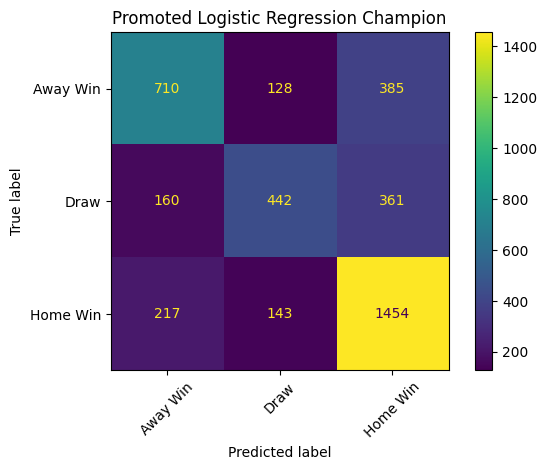

In [0]:
class_labels = list(
    champion_model.named_steps[
        "classifier"
    ].classes_
)

champion_confusion_matrix = confusion_matrix(
    y_test,
    champion_predictions,
    labels=class_labels
)

matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=champion_confusion_matrix,
    display_labels=class_labels
)

matrix_display.plot(
    values_format="d"
)

plt.title(
    "Promoted Logistic Regression Champion"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
prediction_results_df = pd.DataFrame(
    {
        "actual_result": (
            y_test.reset_index(drop=True)
        ),
        "predicted_result": (
            pd.Series(champion_predictions)
        )
    }
)

prediction_results_df[
    "prediction_correct"
] = (
    prediction_results_df["actual_result"]
    == prediction_results_df["predicted_result"]
)

prediction_results_df[
    "prediction_confidence"
] = np.max(
    champion_probabilities,
    axis=1
)

In [0]:
for class_index, class_name in enumerate(
    class_labels
):

    safe_class_name = (
        str(class_name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    prediction_results_df[
        f"probability_{safe_class_name}"
    ] = champion_probabilities[
        :,
        class_index
    ]

display(
    prediction_results_df.head(20)
)

actual_result,predicted_result,prediction_correct,prediction_confidence,probability_away_win,probability_draw,probability_home_win
Away Win,Draw,false,0.70415828526141,0.13313846934779508,0.70415828526141,0.16270324539079506
Draw,Draw,true,0.7349726580447252,0.25982679385023894,0.7349726580447252,0.005200548105035715
Away Win,Away Win,true,0.7402076339574001,0.7402076339574001,0.13105165824700876,0.12874070779559116
Away Win,Home Win,false,0.640927066037839,0.10505155930004896,0.25402137466211205,0.640927066037839
Home Win,Home Win,true,0.4762284536875322,0.2683586911829187,0.25541285512954903,0.4762284536875322
Away Win,Home Win,false,0.7500371521384889,0.059867094156737785,0.1900957537047732,0.7500371521384889
Home Win,Away Win,false,0.6539319800565763,0.6539319800565763,0.0038677013025475576,0.3422003186408762
Draw,Home Win,false,0.47289797451126164,0.30241914670396314,0.22468287878477533,0.47289797451126164
Home Win,Home Win,true,0.9990964152005161,1.0223139035240002E-5,8.93361660448634E-4,0.9990964152005161
Draw,Home Win,false,0.43209036962273706,0.3304644826588471,0.23744514771841582,0.43209036962273706


In [0]:
prediction_results_df.to_csv(
    INFERENCE_RESULTS_PATH,
    index=False
)

prediction_results_df.head(25).to_csv(
    SAMPLE_PREDICTIONS_PATH,
    index=False
)

print(
    "Complete predictions saved to:",
    INFERENCE_RESULTS_PATH
)

print(
    "Prediction sample saved to:",
    SAMPLE_PREDICTIONS_PATH
)

Complete predictions saved to: /Volumes/workspace/default/football_data/promoted_champion_predictions.csv
Prediction sample saved to: /Volumes/workspace/default/football_data/promoted_champion_prediction_sample.csv


In [0]:
inference_summary_df = pd.DataFrame(
    [
        {
            "registered_model_name":
                REGISTERED_MODEL_NAME,
            "model_alias":
                CHAMPION_ALIAS,
            "alias_model_uri":
                CHAMPION_MODEL_URI,
            "resolved_model_version":
                resolved_version,
            "resolved_run_id":
                resolved_run_id,
            "algorithm":
                loaded_classifier_name,
            "test_rows":
                len(X_test_aligned),
            "test_accuracy":
                inference_accuracy,
            "test_precision_macro":
                inference_metrics[
                    "test_precision_macro"
                ],
            "test_recall_macro":
                inference_metrics[
                    "test_recall_macro"
                ],
            "test_f1_macro":
                inference_macro_f1,
            "test_f1_weighted":
                inference_metrics[
                    "test_f1_weighted"
                ],
            "expected_accuracy":
                expected_accuracy,
            "expected_macro_f1":
                expected_macro_f1,
            "accuracy_matches":
                accuracy_matches,
            "macro_f1_matches":
                macro_f1_matches,
            "alias_verification":
                "PASSED",
            "classifier_verification":
                "PASSED",
            "prediction_count_verification":
                "PASSED",
            "model_load_time_seconds":
                model_load_time,
            "prediction_time_seconds":
                prediction_time
        }
    ]
)

inference_summary_df.to_csv(
    INFERENCE_SUMMARY_PATH,
    index=False
)

display(inference_summary_df)

print(
    "Inference summary saved to:",
    INFERENCE_SUMMARY_PATH
)

registered_model_name,model_alias,alias_model_uri,resolved_model_version,resolved_run_id,algorithm,test_rows,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,expected_accuracy,expected_macro_f1,accuracy_matches,macro_f1_matches,alias_verification,classifier_verification,prediction_count_verification,model_load_time_seconds,prediction_time_seconds
workspace.default.football_match_result_model,champion,models:/workspace.default.football_match_result_model@champion,5,80ac2ed817e940c9a66f4e99f15b08f4,LogisticRegression,4000,0.6515,0.6446662708271728,0.6136885178601231,0.6222097633743984,0.6434775072688667,0.6515,0.6222097633743984,true,true,PASSED,PASSED,PASSED,4.898491144180298,0.05338120460510254


Inference summary saved to: /Volumes/workspace/default/football_data/promoted_champion_inference_summary.csv


In [0]:
required_output_files = [
    INFERENCE_RESULTS_PATH,
    SAMPLE_PREDICTIONS_PATH,
    INFERENCE_SUMMARY_PATH
]

for output_path in required_output_files:

    assert os.path.exists(output_path), (
        f"Output file missing: {output_path}"
    )

saved_results_df = pd.read_csv(
    INFERENCE_RESULTS_PATH
)

saved_summary_df = pd.read_csv(
    INFERENCE_SUMMARY_PATH
)

assert len(saved_results_df) == 4000, (
    f"Expected 4000 inference rows, "
    f"but found {len(saved_results_df)}."
)

assert len(saved_summary_df) == 1, (
    f"Expected 1 summary row, "
    f"but found {len(saved_summary_df)}."
)

saved_algorithm = str(
    saved_summary_df.iloc[0][
        "algorithm"
    ]
).strip()

saved_version = str(
    int(
        float(
            saved_summary_df.iloc[0][
                "resolved_model_version"
            ]
        )
    )
)

expected_algorithm = str(
    champion_info_df.iloc[0][
        "algorithm"
    ]
).strip()

expected_version = str(
    int(
        float(
            champion_info_df.iloc[0][
                "registered_model_version"
            ]
        )
    )
)

assert saved_algorithm == "LogisticRegression", (
    f"Expected LogisticRegression, "
    f"but found {saved_algorithm}."
)

assert saved_algorithm == expected_algorithm, (
    "Inference algorithm does not match "
    "the current Champion algorithm."
)

assert saved_version == expected_version, (
    "Inference model version does not match "
    "the current Champion version. "
    f"Inference version: {saved_version}, "
    f"Champion version: {expected_version}."
)

print("Saved inference outputs validated.")
print("Algorithm:", saved_algorithm)
print("Resolved model version:", saved_version)
print("Inference rows:", len(saved_results_df))

Saved inference outputs validated.
Algorithm: LogisticRegression
Resolved model version: 5
Inference rows: 4000


In [0]:
print("=" * 72)
print("NOTEBOOK 8 COMPLETED SUCCESSFULLY")
print("=" * 72)

print(
    "Registered model:",
    REGISTERED_MODEL_NAME
)

print(
    "Stable model URI:",
    CHAMPION_MODEL_URI
)

print(
    "Resolved Champion version:",
    resolved_version
)

print(
    "Resolved Champion run ID:",
    resolved_run_id
)

print(
    "Loaded algorithm:",
    loaded_classifier_name
)

print(
    "Test rows:",
    len(X_test_aligned)
)

print(
    "Accuracy:",
    round(inference_accuracy, 4)
)

print(
    "Macro F1:",
    round(inference_macro_f1, 4)
)

print(
    "Accuracy matches Notebook 6:",
    accuracy_matches
)

print(
    "Macro F1 matches Notebook 6:",
    macro_f1_matches
)

print(
    "Alias verification:",
    "PASSED"
)

print(
    "Classifier verification:",
    "PASSED"
)

print(
    "Prediction verification:",
    "PASSED"
)

print(
    "Result: The stable Champion alias successfully "
    "loaded the promoted Logistic Regression model."
)

NOTEBOOK 8 COMPLETED SUCCESSFULLY
Registered model: workspace.default.football_match_result_model
Stable model URI: models:/workspace.default.football_match_result_model@champion
Resolved Champion version: 5
Resolved Champion run ID: 80ac2ed817e940c9a66f4e99f15b08f4
Loaded algorithm: LogisticRegression
Test rows: 4000
Accuracy: 0.6515
Macro F1: 0.6222
Accuracy matches Notebook 6: True
Macro F1 matches Notebook 6: True
Alias verification: PASSED
Classifier verification: PASSED
Prediction verification: PASSED
Result: The stable Champion alias successfully loaded the promoted Logistic Regression model.
